# Chains and cosmological constraints

Loads the CosmoSIS `emcee` chain produced by the HMF+MOR forecast pipeline,
inspects walker traces for burn-in/mixing, and makes a triangle (contour)
plot of the cosmological parameter constraints (`omega_m`, `sigma8_input`).

In [3]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from getdist import MCSamples, plots

# must come after importing getdist.plots, which resets the mpl backend
%matplotlib inline

CHAIN_FILE = Path("../output/scatter_fixed_02_area_A1.txt")

## Load chain + header metadata

In [4]:
def read_cosmosis_chain(path):
    """Parse a CosmoSIS text-sampler output file.

    Returns the data array, the column names, and a dict of the
    `#key=value` header metadata (sampler, walkers, nsteps, etc).
    """
    columns = None
    meta = {}
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):
                break
            if line.startswith("## "):
                continue
            header = line[1:].strip()
            if columns is None:
                columns = header.split()
                continue
            if "=" in header:
                key, _, val = header.partition("=")
                meta[key.strip()] = val.strip()

    data = np.loadtxt(path)
    return data, columns, meta


data, columns, meta = read_cosmosis_chain(CHAIN_FILE)
nwalkers = int(meta["walkers"])
nsteps = data.shape[0] // nwalkers

sampler_name = meta.get("sampler")
print(f"columns: {columns}")
print(f"sampler={sampler_name}  walkers={nwalkers}  steps={nsteps}  rows={data.shape[0]}")

columns: ['cosmological_parameters--omega_m', 'cosmological_parameters--sigma8_input', 'mor_parameters--frac_scatter', 'prior', 'post']
sampler=emcee  walkers=20  steps=500  rows=10000


## Reshape into (walker, step, param)

CosmoSIS's `emcee` sampler writes rows step-major: all walkers for step 0,
then all walkers for step 1, etc.

In [5]:
param_names = [c for c in columns if c not in ("prior", "post")]
param_idx = [columns.index(p) for p in param_names]

chain = data.reshape(nsteps, nwalkers, len(columns)).transpose(1, 0, 2)
log_post = chain[:, :, columns.index("post")]

print(f"parameters: {param_names}")
print(f"chain shape (walkers, steps, cols): {chain.shape}")

parameters: ['cosmological_parameters--omega_m', 'cosmological_parameters--sigma8_input', 'mor_parameters--frac_scatter']
chain shape (walkers, steps, cols): (20, 500, 5)


## Walker traces

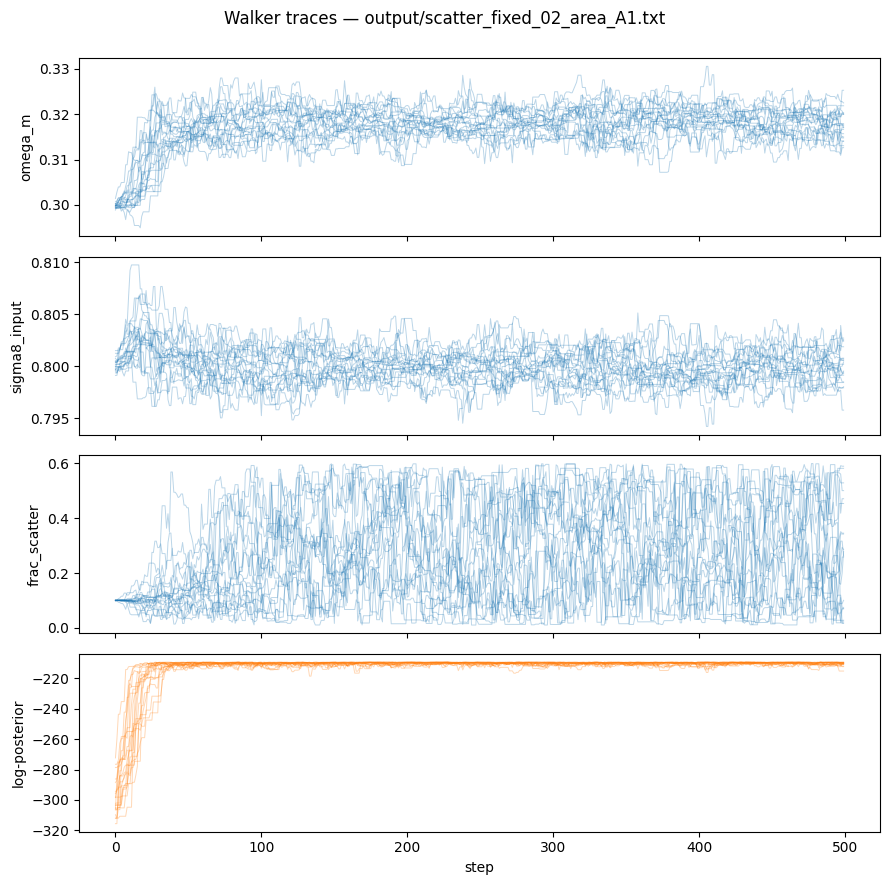

In [6]:
fig, axes = plt.subplots(len(param_names) + 1, 1, figsize=(9, 2.2 * (len(param_names) + 1)), sharex=True)

for i, name in enumerate(param_names):
    ax = axes[i]
    for w in range(nwalkers):
        ax.plot(chain[w, :, param_idx[i]], color="C0", alpha=0.3, lw=0.7)
    ax.set_ylabel(name.split("--")[-1])

ax = axes[-1]
for w in range(nwalkers):
    ax.plot(log_post[w], color="C1", alpha=0.3, lw=0.7)
ax.set_ylabel("log-posterior")
ax.set_xlabel("step")

fig.suptitle("Walker traces — output/scatter_fixed_02_area_A1.txt", y=1.0)
fig.tight_layout()
plt.show()

## Burn-in cut

Adjust `burnin_frac` after looking at the traces above — the walkers should
look like a stationary "fuzzy caterpillar" past the burn-in point.

In [7]:
burnin_frac = 0.5
burnin_steps = int(burnin_frac * nsteps)

flat_samples = chain[:, burnin_steps:, :].reshape(-1, len(columns))
flat_params = flat_samples[:, param_idx]
flat_post = flat_samples[:, columns.index("post")]

print(f"discarding first {burnin_steps}/{nsteps} steps as burn-in")
print(f"flattened samples: {flat_params.shape[0]}")

discarding first 250/500 steps as burn-in
flattened samples: 5000


## Triangle plot of cosmological constraints

Removed no burn in


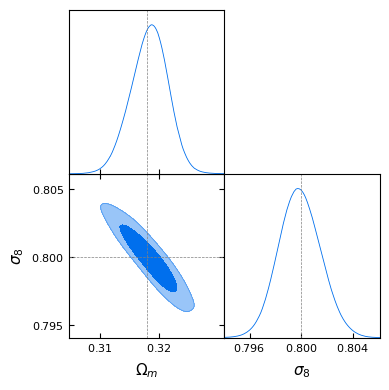

In [9]:
labels = {
    "cosmological_parameters--omega_m": r"\Omega_m",
    "cosmological_parameters--sigma8_input": r"\sigma_8",
}
param_labels = [labels.get(p, p) for p in param_names]

samples = MCSamples(
    samples=flat_params,
    names=param_names,
    labels=param_labels,
    label="v1",
)

# fiducial values used to generate the mock data (see mass_function_like config)
fiducial = {
    "cosmological_parameters--omega_m": 0.318,
    "cosmological_parameters--sigma8_input": 0.80,
}
markers = {p: fiducial[p] for p in param_names if p in fiducial}

plot_params = [
    "cosmological_parameters--omega_m",
    "cosmological_parameters--sigma8_input",
]

g = plots.get_subplot_plotter()
g.triangle_plot(samples, plot_params, filled=True, markers=markers)
plt.show()

## 1D marginalized constraints

In [10]:
for p, lbl in zip(param_names, param_labels):
    stats = samples.getMargeStats().parWithName(p)
    print(f"{lbl:>10s} = {stats.mean:.4f} +/- {stats.err:.4f}")

  \Omega_m = 0.3183 +/- 0.0031
  \sigma_8 = 0.7999 +/- 0.0016
mor_parameters--frac_scatter = 0.2932 +/- 0.1736


## Comparing `config_key` assumptions

`scripts/xxx.sh` refits the same mock data
(generated with `frac_scatter_data = 0.20` fixed) while scanning the
*assumed* model-side scatter, `frac_scatter_model`, away from that true
value. `xxx.txt` itself is the matched case (`frac_scatter_model = 0.20`).
Overlaying the resulting constraints shows how a mismatch between the
assumed and true scatter biases and broadens `omega_m` / `sigma8_input`.

In [34]:
def load_scatter_run(path, burnin_frac=0.5, label=None):
    """Read a chain file and return a burnin-cut getdist MCSamples."""
    data_, columns_, meta_ = read_cosmosis_chain(path)
    nwalkers_ = int(meta_["walkers"])
    nsteps_ = data_.shape[0] // nwalkers_
    chain_ = data_.reshape(nsteps_, nwalkers_, len(columns_)).transpose(1, 0, 2)
    burnin_steps_ = int(burnin_frac * nsteps_)

    pnames_ = [c for c in columns_ if c not in ("prior", "post")]
    pidx_ = [columns_.index(p) for p in pnames_]
    flat_ = chain_[:, burnin_steps_:, :].reshape(-1, len(columns_))

    return MCSamples(
        samples=flat_[:, pidx_],
        names=pnames_,
        labels=[labels.get(p, p) for p in pnames_],
        label=label,
    )


# (path, config_value) — frac_scatter_data is fixed at 0.20 for all of them
scan_runs = [
    ("../output/scatter_fixed_02_area_A1.txt", 1000),
    ("../output/scatter_fixed_02_area_A2.txt", 2000),
    ("../output/scatter_fixed_02_sm20.txt", 4000),
    ("../output/scatter_fixed_02_area_A8.txt", 8000),
    #("../output/scatter_fixed_02_sm40.txt", 0.40),
]

# categorical palette (fixed hue order, CVD-safe) — 5 runs need to be told apart
# at a glance, which a single-hue light->dark ramp does not give at thin contour
# linewidths, so identity beats magnitude-encoding here
plot_colors = ["#2a78d6", "#eda100", "#008300", "#4a3aa7"] #"#1baf7a",

scan_samples = [
    load_scatter_run(path, label=rf"${config_value:.0f}\,{{\rm deg}}^2$")
    for path, config_value in scan_runs
]

for (path, config_value), s in zip(scan_runs, scan_samples):
    print(f"{path}: area_deg2={config_value:.0f}  samples={s.numrows}")

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
../output/scatter_fixed_02_area_A1.txt: area_deg2=1000  samples=5000
../output/scatter_fixed_02_area_A2.txt: area_deg2=2000  samples=5000
../output/scatter_fixed_02_sm20.txt: area_deg2=4000  samples=5000
../output/scatter_fixed_02_area_A8.txt: area_deg2=8000  samples=5000


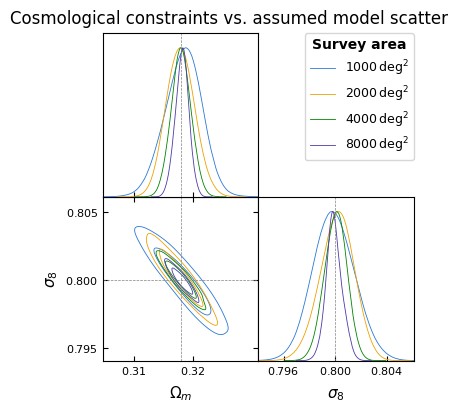

In [35]:
g = plots.get_subplot_plotter()
g.triangle_plot(
    scan_samples,
    plot_params,
    filled=False,
    contour_colors=plot_colors,
    markers=markers,
    legend_labels=[s.label for s in scan_samples],
    legend_loc="upper right",
)

# Move the legend to sit outside the plot area
leg = g.legend
#leg.set_bbox_to_anchor((1.00, 0.95))     # x>1 pushes it to the right of the figure
leg.set_title("Survey area", prop={"size": 10, "weight": "bold"})
#leg.set_frame_on(False)                   # optional: cleaner without the box

g.fig.suptitle("Cosmological constraints vs. assumed model scatter", y=1.02)
#plt.tight_layout()
plt.show()

### Constraint shift vs. scatter mismatch

Mean ± 1σ for each parameter as a function of the assumed
`frac_scatter_model`, with the matched run (`frac_scatter_model =
frac_scatter_data = 0.10`) marked by the dashed vertical line and the
fiducial truth by the dashed horizontal line. Point colors match the runs
in the triangle plot above.

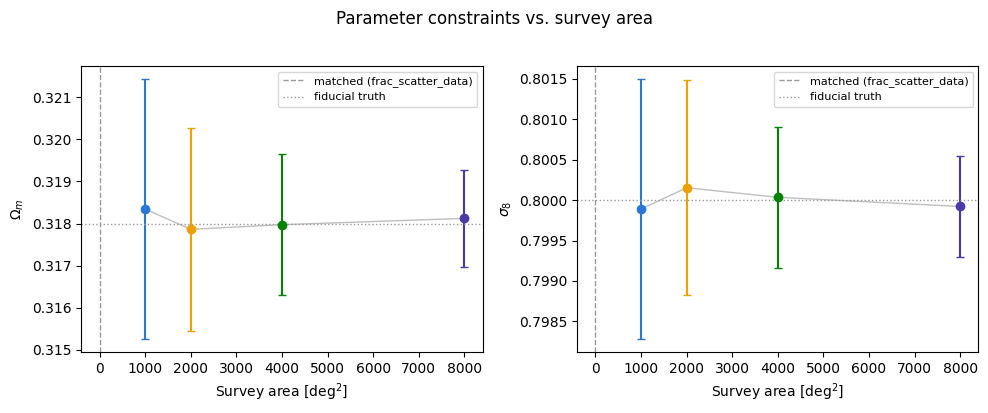

In [38]:
fig, axes = plt.subplots(1, len(plot_params), figsize=(5 * len(plot_params), 4))

config_values = [config_value for _, config_value in scan_runs]
for i, (p, lbl) in enumerate(zip(plot_params, param_labels)):
    ax = axes[i]
    means = []
    errs = []
    for s in scan_samples:
        stats = s.getMargeStats().parWithName(p)
        means.append(stats.mean)
        errs.append(stats.err)

    ax.plot(config_values, means, "-", color="0.75", lw=1, zorder=1)
    for config_value, mean, err, color in zip(config_values, means, errs, plot_colors):
        ax.errorbar(config_value, mean, yerr=err, fmt="o", color=color, ecolor=color,
                     capsize=3, zorder=2)
    ax.axvline(0.10, color="0.6", ls="--", lw=1, label="matched (frac_scatter_data)")
    if p in fiducial:
        ax.axhline(fiducial[p], color="0.6", ls=":", lw=1, label="fiducial truth")
    ax.set_xlabel(r"Survey area [deg$^2$]")
    ax.set_ylabel(f"${lbl}$")
    ax.legend(fontsize=8)

fig.suptitle("Parameter constraints vs. survey area", y=1.02)
fig.tight_layout()
plt.show()